# Assignment 1 - Exploratory Data Analysis (Fashion-MNIST)

**Course:** CO3133 Deep Learning and Its Applications, Semester-261
**Milestone:** A1-M1 Draft

This notebook covers the EDA items required by the handbook (Section 13): **class
distribution**, **input size**, **imbalance analysis**, and **representative samples**.
It also records the split sizes, the normalization constants, and one example batch after
preprocessing, which Part 1 of the report needs.

MNIST is used only for debugging elsewhere; all analysis here is on **Fashion-MNIST**,
the dataset that carries the main results.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
from IPython.display import Image, display

from src.data.dataset import DATASETS, get_dataloaders
from src.utils.plots import plot_class_distribution, plot_sample_grid
from src.utils.seed import set_seed

FIGURES = ROOT / "outputs" / "eda"
FIGURES.mkdir(parents=True, exist_ok=True)
set_seed(42)

[seed] set to 42


## 1. Dataset, input size and split

The split is produced once by `src/data/dataset.py` and reused by every model, so the
comparison is fair: same partitions, same seed, same preprocessing.

In [2]:
loaders, info = get_dataloaders(dataset="fashion_mnist", data_root=str(ROOT / "data"), seed=42)

print("dataset       :", info["dataset"])
print("classes       :", info["num_classes"], "->", info["classes"])
print("input shape   :", tuple(info["input_shape"]), "(C, H, W) = 784 pixels when flattened")
print("split sizes   :", info["split_sizes"])
print("split policy  : stratified =", info["stratified"],
      "| val fraction =", info["val_fraction"], "| seed =", info["seed"])
print("normalization : mean =", info["normalize"]["mean"], "std =", info["normalize"]["std"])
print("augmentation  :", info["augment"])

dataset       : fashion_mnist
classes       : 10 -> ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
input shape   : (1, 28, 28) (C, H, W) = 784 pixels when flattened
split sizes   : {'train': 54000, 'val': 6000, 'test': 10000}
split policy  : stratified = True | val fraction = 0.1 | seed = 42
normalization : mean = 0.286 std = 0.353
augmentation  : False


Train and validation come from the official 60,000-image training set; the official
10,000-image test set is untouched during training and is only read by `scripts/eval.py`.
Splitting *within* the training set is what prevents test leakage.

## 2. Class distribution

In [3]:
counts = info["class_counts"]
header = f"{'class':<14}{'train':>8}{'val':>7}{'test':>7}{'train share':>13}"
print(header)
print("-" * len(header))
for idx, name in enumerate(info["classes"]):
    share = 100 * counts["train"][idx] / info["split_sizes"]["train"]
    print(f"{name:<14}{counts['train'][idx]:>8}{counts['val'][idx]:>7}"
          f"{counts['test'][idx]:>7}{share:>12.2f}%")

class            train    val   test  train share
-------------------------------------------------
T-shirt/top       5400    600   1000       10.00%
Trouser           5400    600   1000       10.00%
Pullover          5400    600   1000       10.00%
Dress             5400    600   1000       10.00%
Coat              5400    600   1000       10.00%
Sandal            5400    600   1000       10.00%
Shirt             5400    600   1000       10.00%
Sneaker           5400    600   1000       10.00%
Bag               5400    600   1000       10.00%
Ankle boot        5400    600   1000       10.00%


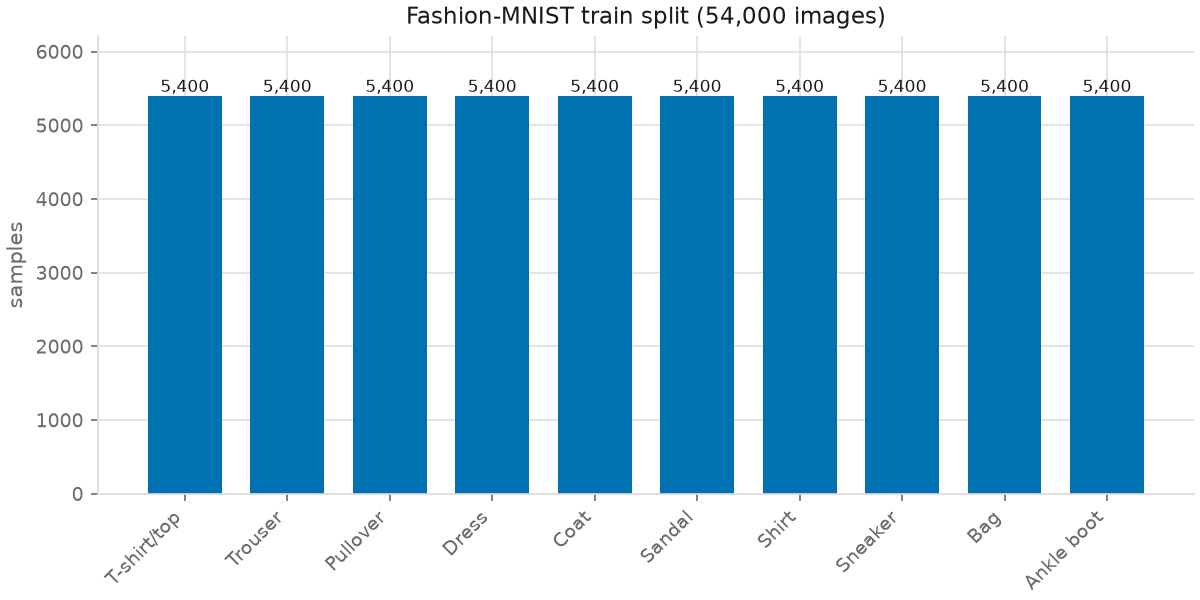

In [4]:
for split in ("train", "val", "test"):
    plot_class_distribution(
        counts[split], info["classes"], FIGURES / f"class_distribution_{split}.png",
        title=f"Fashion-MNIST {split} split ({info['split_sizes'][split]:,} images)")

display(Image(filename=str(FIGURES / "class_distribution_train.png")))

## 3. Imbalance analysis

Two quantitative checks instead of an eyeball judgement: the **imbalance ratio**
(largest class / smallest class, 1.0 = balanced) and the **normalized entropy** of the
class shares (1.0 = uniform).

In [5]:
train_counts = np.array(counts["train"])
shares = train_counts / train_counts.sum()
normalized_entropy = -(shares * np.log(shares)).sum() / np.log(len(shares))

print(f"per-class min / max  : {train_counts.min()} / {train_counts.max()}")
print(f"imbalance ratio      : {train_counts.max() / train_counts.min():.4f}   (1.0 = balanced)")
print(f"normalized entropy   : {normalized_entropy:.4f}   (1.0 = uniform)")
print(f"majority class share : {100 * shares.max():.2f}%")
print(f"random-guess accuracy: {100 / info['num_classes']:.1f}%")

per-class min / max  : 5400 / 5400
imbalance ratio      : 1.0000   (1.0 = balanced)
normalized entropy   : 1.0000   (1.0 = uniform)
majority class share : 10.00%
random-guess accuracy: 10.0%


**Reading.** Fashion-MNIST holds exactly 6,000 training images per class, and the
stratified split keeps that ratio, so the imbalance ratio is 1.0 and the entropy is 1.0.
Consequences for the experiment design:

- No class weighting, resampling or threshold tuning is needed.
- Accuracy is not inflated by a dominant class, and **macro-F1 stays close to accuracy**;
  a gap between the two therefore signals *per-class* weakness, not imbalance.
- The trivial baseline to beat is 10% (random) / 10% (majority class).

## 4. Representative samples

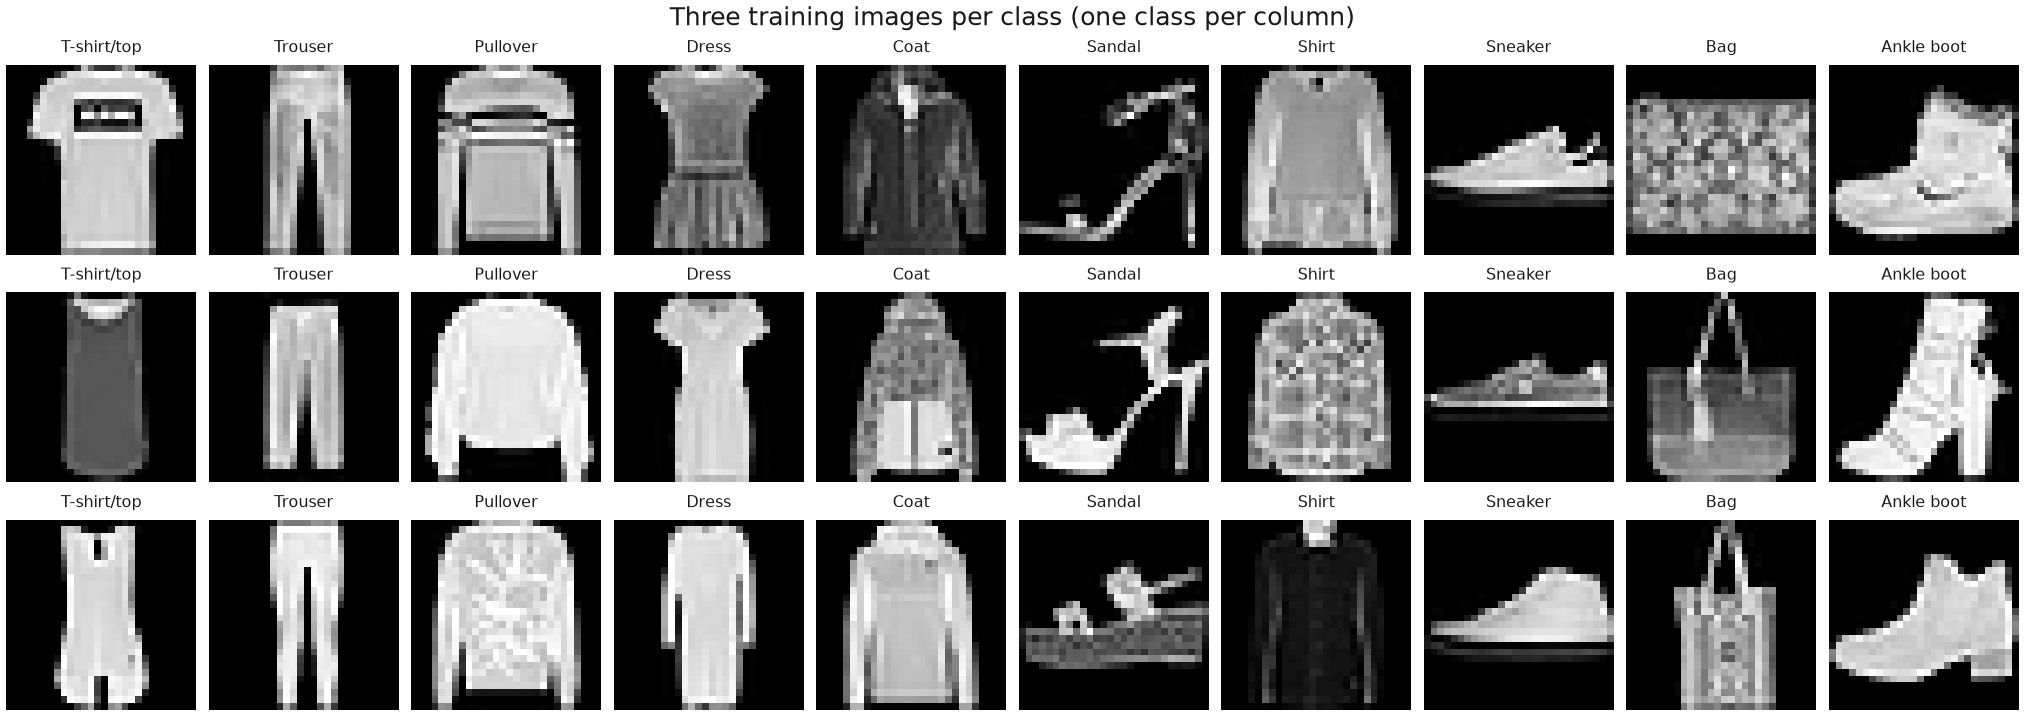

In [6]:
raw = DATASETS["fashion_mnist"]["cls"](str(ROOT / "data"), train=True, download=False)
targets = raw.targets.numpy()
per_class = {c: np.flatnonzero(targets == c)[:3] for c in range(info["num_classes"])}

images, labels = [], []
for row in range(3):
    for class_idx in range(info["num_classes"]):
        position = per_class[class_idx][row]
        images.append(np.asarray(raw[position][0], dtype=np.float32) / 255.0)
        labels.append(class_idx)

plot_sample_grid(images, labels, info["classes"], FIGURES / "samples_per_class.png",
                 ncols=info["num_classes"],
                 title="Three training images per class (one class per column)")
display(Image(filename=str(FIGURES / "samples_per_class.png")))

## 5. Pixel statistics

This is where the normalization constants in `src/data/dataset.py` come from - they are
measured on the training images, not copied from a tutorial.

In [7]:
pixels = raw.data.numpy().astype(np.float32) / 255.0

print(f"stored tensor        : dtype {raw.data.dtype}, shape {tuple(raw.data.shape)}")
print(f"value range after /255: {pixels.min():.3f} - {pixels.max():.3f}")
print(f"mean / std over 60k   : {pixels.mean():.4f} / {pixels.std():.4f}")
print(f"constants in use      : {info['normalize']}")
print(f"exactly-zero pixels   : {100 * (pixels == 0).mean():.1f}%  (black background)")
print(f"storage size (train)  : {raw.data.numpy().nbytes / 1024**2:.1f} MiB as uint8")

stored tensor        : dtype torch.uint8, shape (60000, 28, 28)
value range after /255: 0.000 - 1.000


mean / std over 60k   : 0.2860 / 0.3530
constants in use      : {'mean': 0.286, 'std': 0.353}
exactly-zero pixels   : 50.2%  (black background)
storage size (train)  : 44.9 MiB as uint8


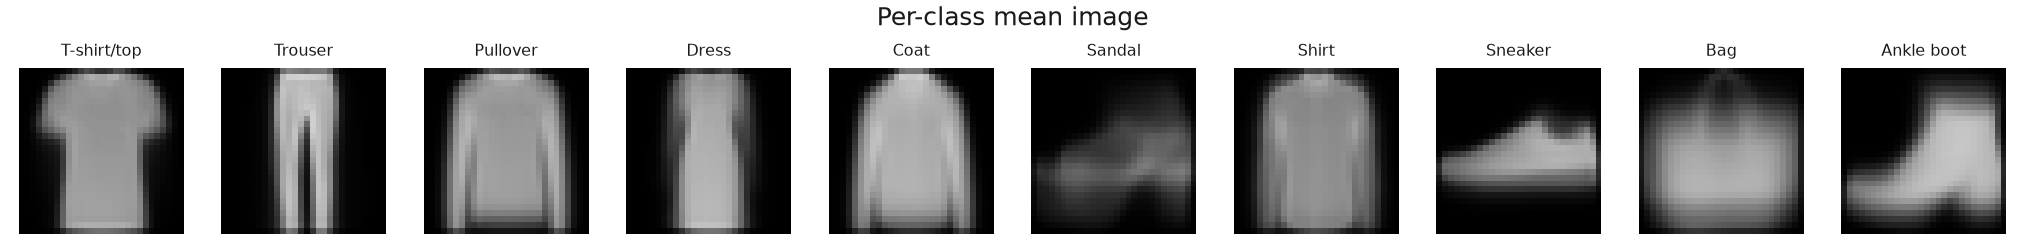

In [8]:
mean_images = [pixels[targets == c].mean(axis=0) for c in range(info["num_classes"])]
plot_sample_grid(mean_images, list(range(info["num_classes"])), info["classes"],
                 FIGURES / "class_mean_images.png", ncols=info["num_classes"],
                 title="Per-class mean image")
display(Image(filename=str(FIGURES / "class_mean_images.png")))

**Reading.** The per-class mean images are sharp silhouettes because every item is
centred and size-normalized. Two consequences that the model comparison will test:

- A **linear model on flattened pixels** can already separate classes whose silhouettes
  differ globally (Trouser, Bag, Sneaker), because those are close to linearly separable
  in pixel space.
- The upper-body garments (T-shirt/top, Pullover, Coat, Shirt) share almost the same
  silhouette and differ mainly in *local texture and edges*. Those are the classes where
  a flattened-pixel model should fail and where a CNN's spatial inductive bias should
  help - the hypothesis the M2 comparison checks.

## 6. One example batch after preprocessing

The exact tensor that reaches the model, as required by Part 1 of the report.

In [9]:
batch_images, batch_labels = next(iter(loaders["train"]))

print("images :", tuple(batch_images.shape), batch_images.dtype)
print("labels :", tuple(batch_labels.shape), batch_labels.dtype)
print(f"range  : {batch_images.min():.3f} .. {batch_images.max():.3f}")
print(f"mean / std : {batch_images.mean():.4f} / {batch_images.std():.4f}"
      "   (~0 / ~1 after Normalize)")
print("flattened for Linear/MLP :", tuple(batch_images.flatten(1).shape))
print("first 16 labels :", batch_labels[:16].tolist())

images : (128, 1, 28, 28) torch.float32
labels : (128,) torch.int64
range  : -0.810 .. 2.023
mean / std : 0.0073 / 0.9989   (~0 / ~1 after Normalize)
flattened for Linear/MLP : (128, 784)
first 16 labels : [2, 2, 5, 3, 1, 2, 0, 4, 3, 5, 9, 4, 4, 6, 0, 1]


## Summary for the report

| Item | Value |
|---|---|
| Dataset | Fashion-MNIST (main results); MNIST for debugging only |
| Input | 1x28x28 grayscale, 784 features when flattened |
| Classes | 10, balanced (imbalance ratio 1.0, normalized entropy 1.0) |
| Split | 54,000 train / 6,000 val (stratified, seed 42) / 10,000 official test |
| Preprocessing | ToTensor, Normalize(mean 0.2860, std 0.3530); no augmentation in the draft |
| Trivial baseline | 10% accuracy |
| Expected hard classes | Shirt vs T-shirt/top vs Pullover vs Coat |